# Diseño de filtros 
vamos a realizar el diseño de dos filtros (un IIR y un FIR) en base a la siguiente plantilla

ws1 = 0.1 #Hz
wp1 = 0.5 #Hz
wp2 = 30.0 #Hz
ws2 = 45.0 #Hz

In [42]:
import scipy.signal as sig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.io as sio
from pytc2.sistemas_lineales import plot_plantilla


In [43]:
fig_sz_x = 10
fig_sz_y = 7
fig_dpi = 100 # dpi

fig_font_size = 16

mpl.rcParams['figure.figsize'] = (fig_sz_x,fig_sz_y)
plt.rcParams.update({'font.size':fig_font_size})

In [44]:
sio.whosmat("ECG_TP4.mat")
mat_struct = sio.loadmat("ECG_TP4.mat")

ecg_lead = mat_struct["ecg_lead"].flatten()
qrs_detections = mat_struct["qrs_detections"].flatten()




In [45]:
# Parameters
hb_length = 600
hb_start = -250
hb_end = 350
half_length = int(hb_length // 2)

heartbeats = [ecg_lead[int(q + hb_start): int(q + hb_end)] for q in qrs_detections]
heartbeats_dt = [sig.detrend(h) for h in heartbeats]
heartbeats_dt = heartbeats_dt / np.max(np.abs(heartbeats_dt), axis=1, keepdims=True)

In [46]:
fs = 1000 # Hz
nyq_frec = fs / 2

In [47]:
ripple = 0.5 # dB
atenuacion = 40 # dB

ws1 = 0.1 #Hz
wp1 = 0.5 #Hz
wp2 = 40.0 #Hz
ws2 = 45.0 #Hz


frecs = np.array([0.0,         ws1,         wp1,     wp2,     ws2,         nyq_frec   ]) / nyq_frec
wp = np.array([wp1, wp2]) / nyq_frec
ws = np.array([ws1, ws2]) / nyq_frec
gains = np.array([-atenuacion, -atenuacion, -ripple, -ripple, -atenuacion, -atenuacion])
gains = 10**(gains/20)



# Filtro IIR

Realizamos el diseño de un filtro IIR tipo cheby1 obteniendo sus coeficientes como secciones de segundo order ya que 
en general, se recomienda usar la forma de secciones de segundo orden (‘sos’) porque calcular los coeficientes para la forma numerador/denominador (‘ba’) puede generar inestabilidades numéricas. segùn la [documentacion de SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.iirdesign.html)

In [48]:
bp_chevy = sig.iirdesign(
    wp=wp, ws=ws, gpass=ripple, gstop=atenuacion, ftype="cheby1", output='sos')

/var/folders/rf/3frjb3md42s8fp_lvn8fwj7c0000gn/T/ipykernel_1212/637304639.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.plot(w / np.pi, 20 * np.log10(abs(h)), 'b')


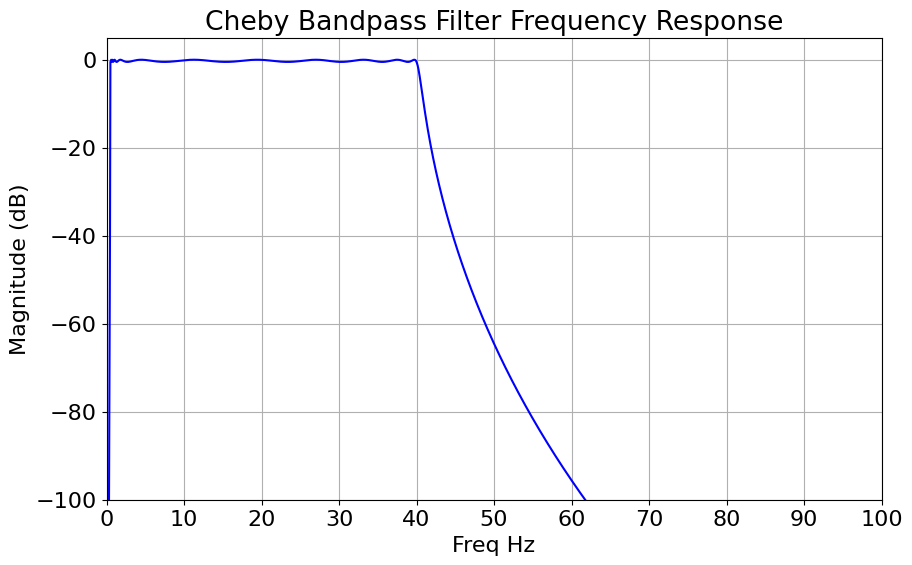

In [49]:
w, h = sig.sosfreqz(bp_chevy, worN=10000)
w = w*nyq_frec

plt.figure(figsize=(10, 6))
plt.plot(w / np.pi, 20 * np.log10(abs(h)), 'b')
plt.title("Cheby Bandpass Filter Frequency Response")
plt.xlabel("Freq Hz")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 100)  # Limit the x-axis to 0-100 Hz
plt.ylim(-100, 5)  # Adjust the y-axis as needed
plt.grid()
plt.xticks(np.arange(0, 101, 10))
plt.show()



# Filtrado con IIR

procedemos a filtrar la señal utilizando este filtro y observar la diferencia en sus espectros

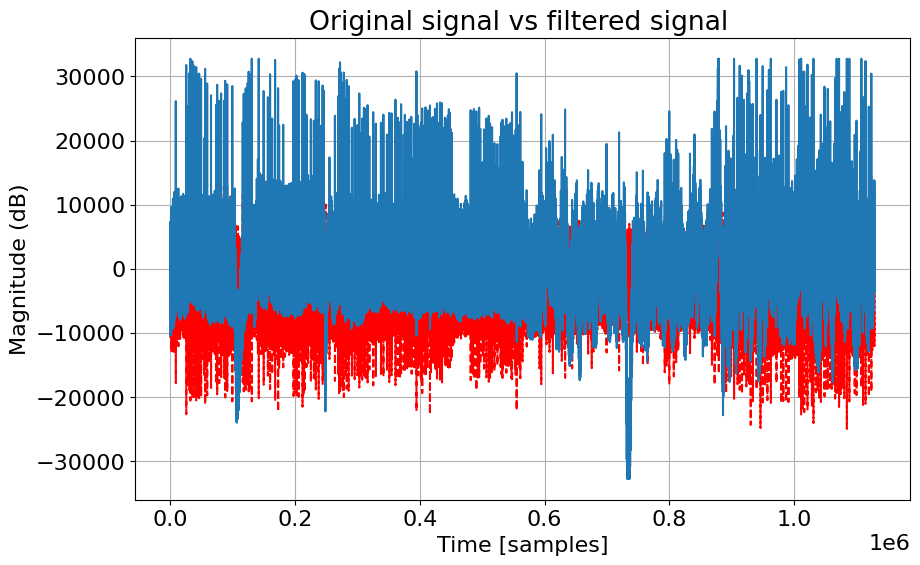

In [50]:
ecg_filter_1 = sig.sosfilt(bp_chevy, ecg_lead)


plt.figure(figsize=(10, 6))
plt.plot(ecg_filter_1, "--r")
plt.plot(ecg_lead)
plt.title("Original signal vs filtered signal ")
plt.xlabel("Time [samples]")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.show()


# Zonas de alta contaminaciòn


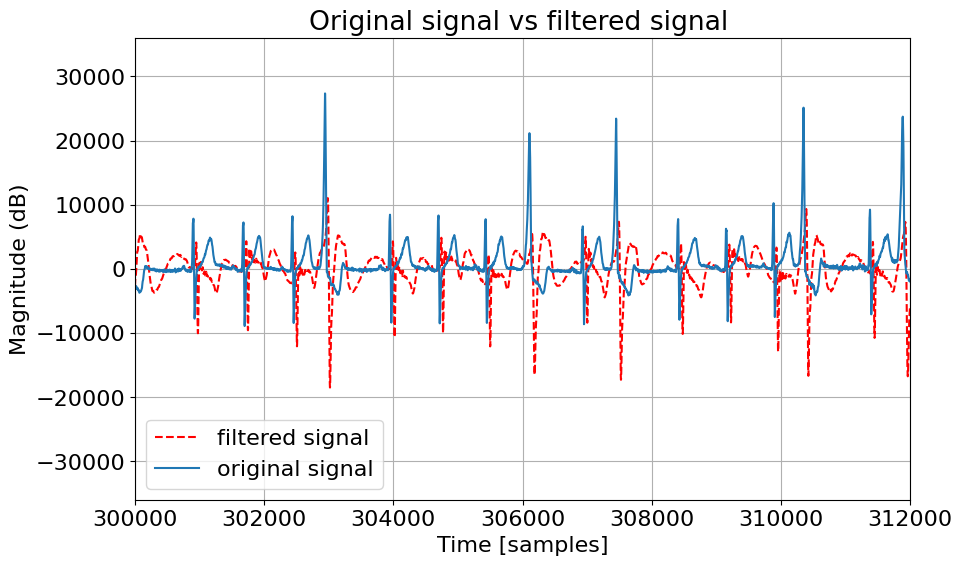

In [51]:
plt.figure(figsize=(10, 6))
plt.plot(ecg_filter_1, "--r", label='filtered signal')
plt.plot(ecg_lead, label='original signal')
plt.title("Original signal vs filtered signal ")
plt.xlabel("Time [samples]")
plt.ylabel("Magnitude (dB)")
plt.xlim(300000,312000)
plt.grid()
plt.legend()

plt.show()

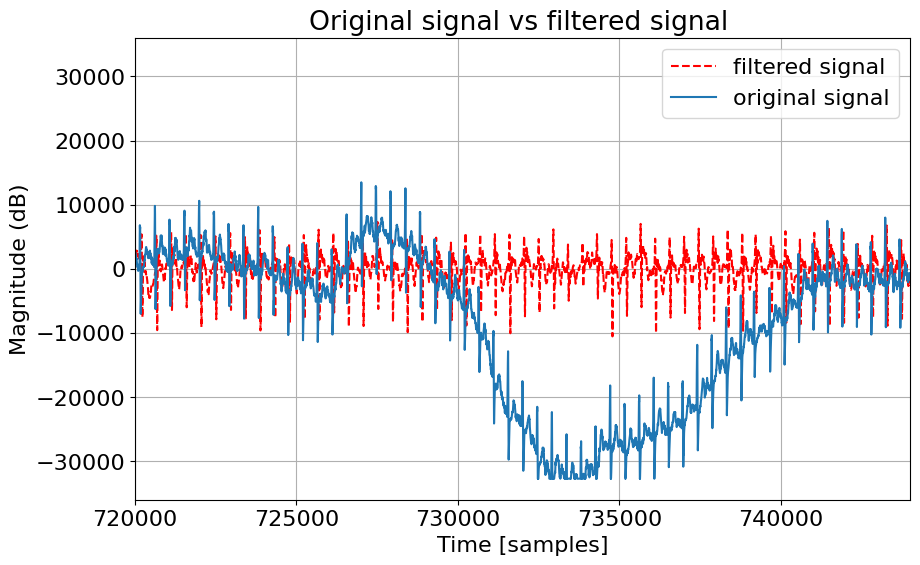

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(ecg_filter_1, "--r", label='filtered signal')
plt.plot(ecg_lead, label='original signal')
plt.title("Original signal vs filtered signal ")
plt.xlabel("Time [samples]")
plt.ylabel("Magnitude (dB)")
plt.xlim(720000,744000)
plt.grid()
plt.legend()

plt.show()

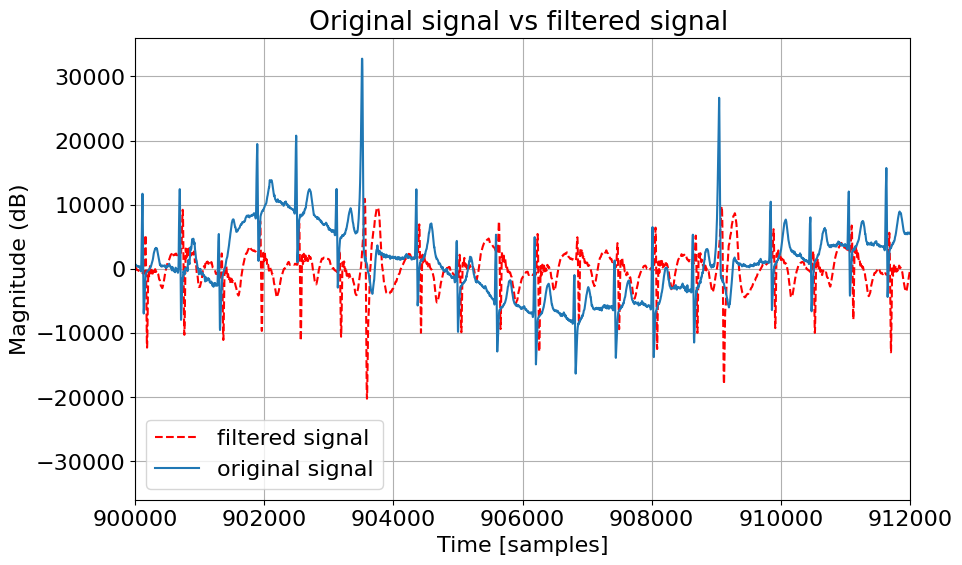

In [53]:
plt.figure(figsize=(10, 6))
plt.plot(ecg_filter_1, "--r", label='filtered signal')
plt.plot(ecg_lead, label='original signal')
plt.title("Original signal vs filtered signal ")
plt.xlabel("Time [samples]")
plt.ylabel("Magnitude (dB)")
plt.xlim(900000,912000)
plt.grid()
plt.legend()

plt.show()

Podemos observar comparando la señal original con la señal filtrada en zonas de alta contaminación que este filtro esta cumpliendo con lo esperado, eliminando tano las oscilaciones lentas (baja frecuencia) como las deformaciònes abruptas y rapidas en la señal (alta freq). 
Cabe mencionar que este filtro añade un retardo a nuestra señal, pero al no ser constante, el tratamiento de este retardo excede el scope de este experimento por lo que será ignorado.

# Zonas de Baja contaminación

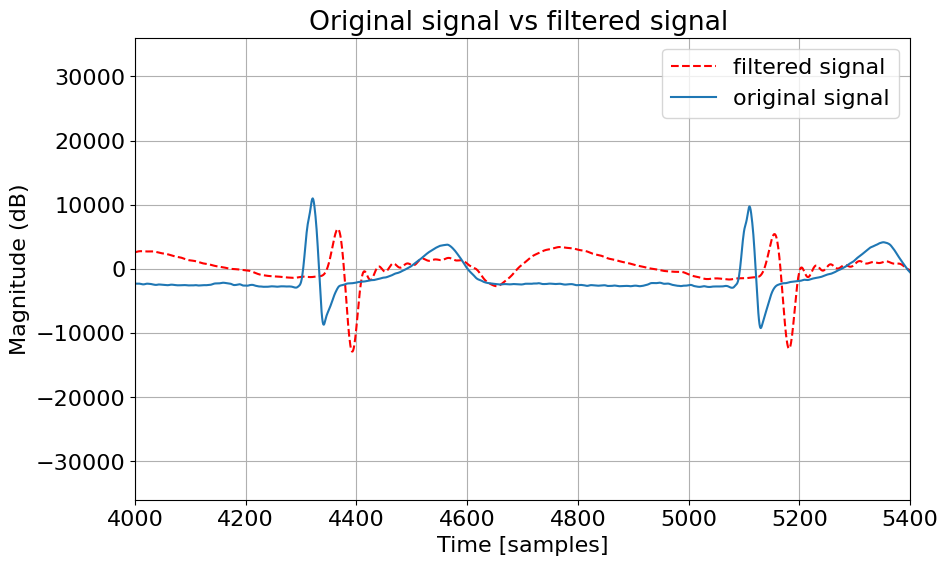

In [54]:
plt.figure(figsize=(10, 6))
plt.plot(ecg_filter_1, "--r", label='filtered signal')
plt.plot(ecg_lead, label='original signal')
plt.title("Original signal vs filtered signal ")
plt.xlabel("Time [samples]")
plt.ylabel("Magnitude (dB)")
plt.xlim(4000,5400)
plt.grid()
plt.legend()

plt.show()

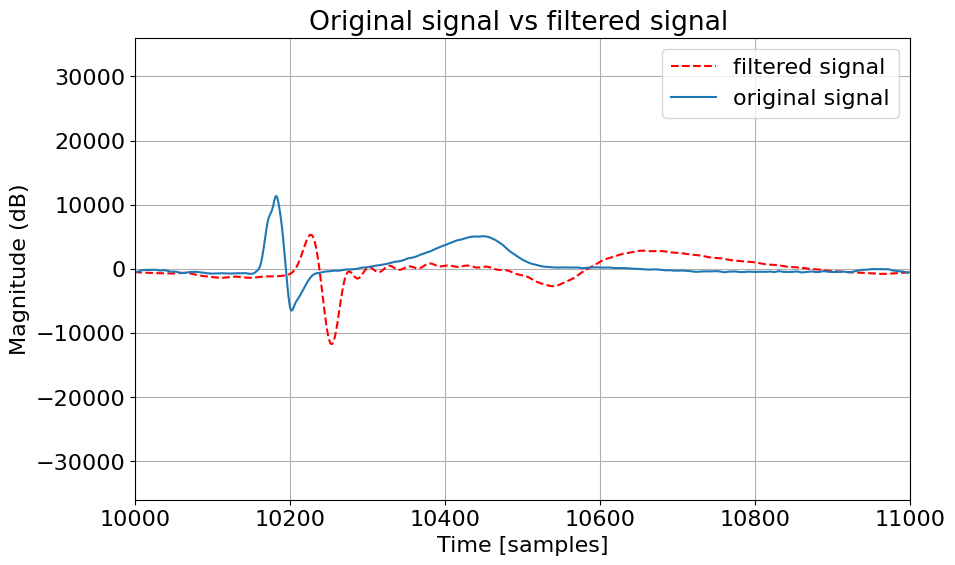

In [55]:
plt.figure(figsize=(10, 6))
plt.plot(ecg_filter_1, "--r", label='filtered signal')
plt.plot(ecg_lead, label='original signal')
plt.title("Original signal vs filtered signal ")
plt.xlabel("Time [samples]")
plt.ylabel("Magnitude (dB)")
plt.xlim(10000,11000)
plt.grid()
plt.legend()

plt.show()

# FIltro FIR
Como primer aproximación a diseñar un filtro FIR utilizaremos el metodo de ventanas, que consta en "ventanear" una respuesta ideal para obtener una respuesta realizabler computacionalmente. Este método es sencillo de implementar pero es subóptimo y resulta en filtros de un orden mayor a otros métodos, que ademas de sumar complejidad a la hora de realizar las cuentas, suman mayor retardo ya que este depende del orden del filtro.

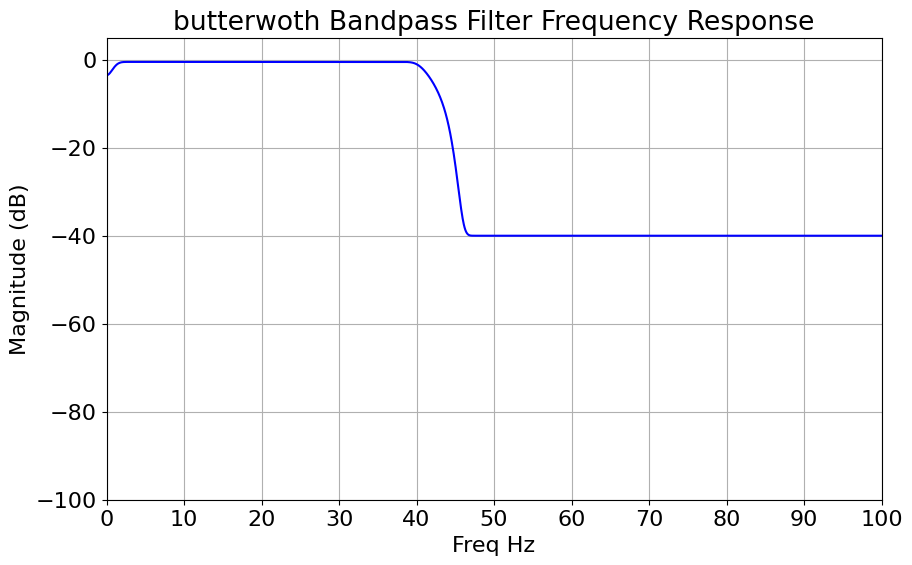

In [56]:
cant_coeficientes = 1501
filter_2_r = (cant_coeficientes - 1) // 2

num_win = sig.firwin2(cant_coeficientes, frecs, gains , window='blackmanharris' )

w, h = sig.freqz(num_win, worN=10000)
w = w*nyq_frec

plt.figure(figsize=(10, 6))
plt.plot(w / np.pi, 20 * np.log10(abs(h)), 'b')
plt.title("butterwoth Bandpass Filter Frequency Response")
plt.xlabel("Freq Hz")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 100)  # Limit the x-axis to 0-100 Hz
plt.ylim(-100, 5)  # Adjust the y-axis as needed
plt.grid()
plt.xticks(np.arange(0, 101, 10))
plt.show()

# Problemas con la plantilla
Podemos observar que aún con un filtro de orden 1500 no podemos satisfacer nuestra plantilla, esto se debe a que esta es muy exigente, especificamente respecto a su frecuencia de corte baja. Para intentar sortear este obstáculo vamos a dividir el filtro en dos etapas, un LPF y un HPF manteniendo las mismas frecuencias de corte.

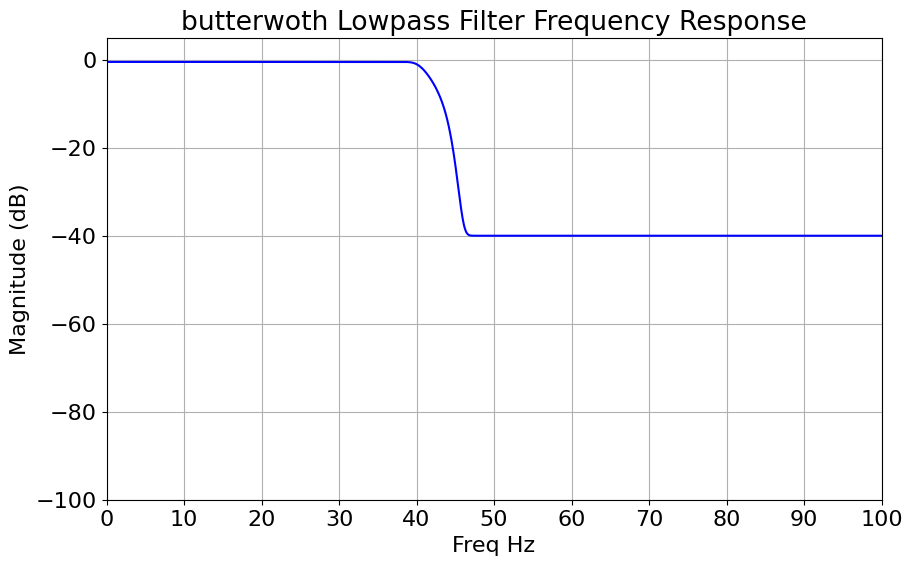

In [57]:
# Low pass filter

ripple = 0.5 # dB
atenuacion = 40 # dB

wpl = 40.0 #Hz
wsl = 45.0 #Hz


frecs_lp = np.array([0.0, wpl, wsl ,nyq_frec]) / nyq_frec
wp = wpl / nyq_frec
ws = wsl / nyq_frec
gains_lp = np.array([-ripple, -ripple, -atenuacion, -atenuacion])
gains_lp = 10**(gains_lp/20)

cant_coeficientes = 1501
filter_lp_r = (cant_coeficientes - 1) // 2

num_win = sig.firwin2(cant_coeficientes, frecs_lp, gains_lp , window='blackmanharris' )

w, h = sig.freqz(num_win, worN=10000)
w = w*nyq_frec

plt.figure(figsize=(10, 6))
plt.plot(w / np.pi, 20 * np.log10(abs(h)), 'b')
plt.title("butterwoth Lowpass Filter Frequency Response")
plt.xlabel("Freq Hz")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 100)  # Limit the x-axis to 0-100 Hz
plt.ylim(-100, 5)  # Adjust the y-axis as needed
plt.grid()
plt.xticks(np.arange(0, 101, 10))
plt.show()

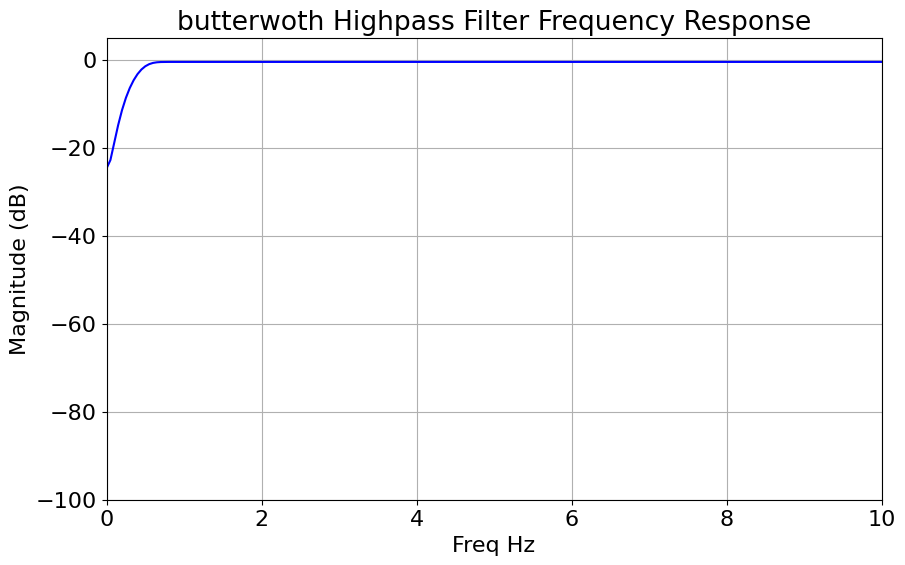

In [58]:
# high pass filter

ripple = 0.5 # dB
atenuacion = 40 # dB

wsh = 0.1 #Hz
wph = 0.5



frecs_h = np.array([0.0, wsh, wph ,nyq_frec]) / nyq_frec
ws = wsh / nyq_frec
gains_h = np.array([-atenuacion, -atenuacion, -ripple, -ripple])
gains_h = 10**(gains_h/20)

cant_coeficientes = 10001
filter_hp_r = (cant_coeficientes - 1) // 2

num_win = sig.firwin2(cant_coeficientes, frecs_h, gains_h , window='blackmanharris' )

w, h = sig.freqz(num_win, worN=10000)
w = w*nyq_frec

plt.figure(figsize=(10, 6))
plt.plot(w / np.pi, 20 * np.log10(abs(h)), 'b')
plt.title("butterwoth Highpass Filter Frequency Response")
plt.xlabel("Freq Hz")
plt.ylabel("Magnitude (dB)")
plt.xlim(0, 10)  # Limit the x-axis to 0-100 Hz
plt.ylim(-100, 5)  # Adjust the y-axis as needed
plt.grid()
plt.show()

# Problemas con la plantilla
Con este último método seguimos sin poder cumplir con la plantilla por lo cual vamos a explorar métodos de diseño de filtros FIR mas eficientes.

# Método de cuadrados mínimos

El método de cuadrados mínimos para el diseño de filtros FIR es una técnica que busca minimizar el error cuadrático entre la respuesta en frecuencia deseada del filtro y la respuesta real del filtro diseñado.

En un principio planteamos la plantilla del pasa banda


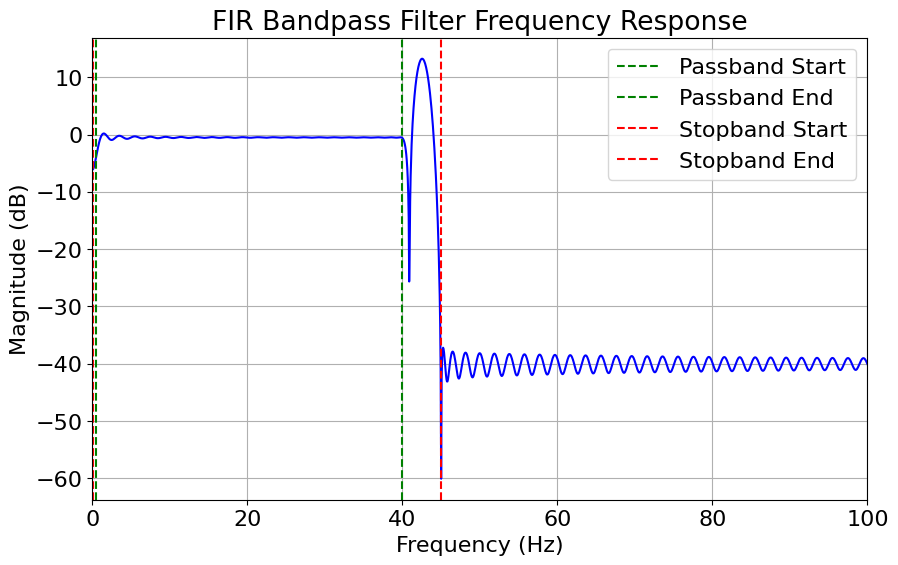

In [59]:
# Filter specifications
fs = 1000  # Sampling frequency (Hz)
nyq = fs / 2  # Nyquist frequency
order = 1000  # Filter order (must be even for bandpass)

# Design the filter using firls
b = sig.firls(order + 1, frecs, gains)

# Frequency response
w, h = sig.freqz(b, worN=8000, fs=fs)

# Plot frequency response
plt.figure(figsize=(10, 6))
plt.plot(w, 20 * np.log10(abs(h)), 'b')
plt.title("FIR Bandpass Filter Frequency Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.axvline(0.5, color='green', linestyle='--', label='Passband Start')
plt.axvline(40, color='green', linestyle='--', label='Passband End')
plt.axvline(0.1, color='red', linestyle='--', label='Stopband Start')
plt.axvline(45, color='red', linestyle='--', label='Stopband End')
plt.xlim(0, 100)  # Limit the x-axis to 0-100 Hz
plt.legend()
plt.show()

# Problemas con la plantilla
Como seguimos sin poder cumplir la plantilla con un orden lógico, vamos a dividir nuevamente en dos etapas, un LPF y un HPF.

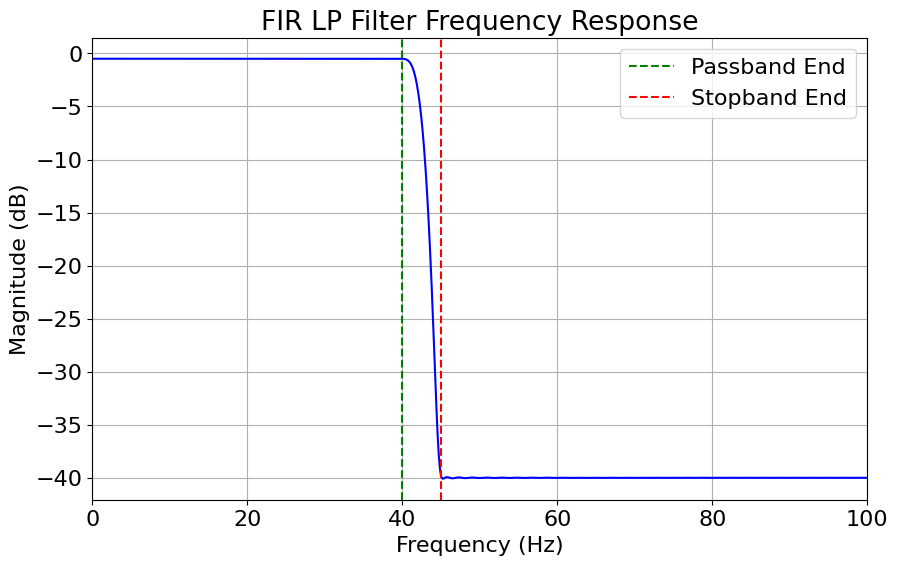

In [60]:
# Low pass

order = 1000  # Filter order (must be even for bandpass)

# Design the filter using firls
bl = sig.firls(order + 1, frecs_lp, gains_lp)

# Frequency response
w, h = sig.freqz(bl, worN=8000, fs=fs)

# Plot frequency response
plt.figure(figsize=(10, 6))
plt.plot(w, 20 * np.log10(abs(h)), 'b')
plt.title("FIR LP Filter Frequency Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.axvline(40, color='green', linestyle='--', label='Passband End')
plt.axvline(45, color='red', linestyle='--', label='Stopband End')
plt.xlim(0, 100)  # Limit the x-axis to 0-100 Hz
plt.legend()
plt.show()

# LPF
En el siguiente gráfico podemos observar que mediante este método podemos cumplir con la plantilla propuesta para bajas frecuencias, por lo que podremos obtener nuestro filtro final convolucionando las respuestas de  ambos filtros diseñados.

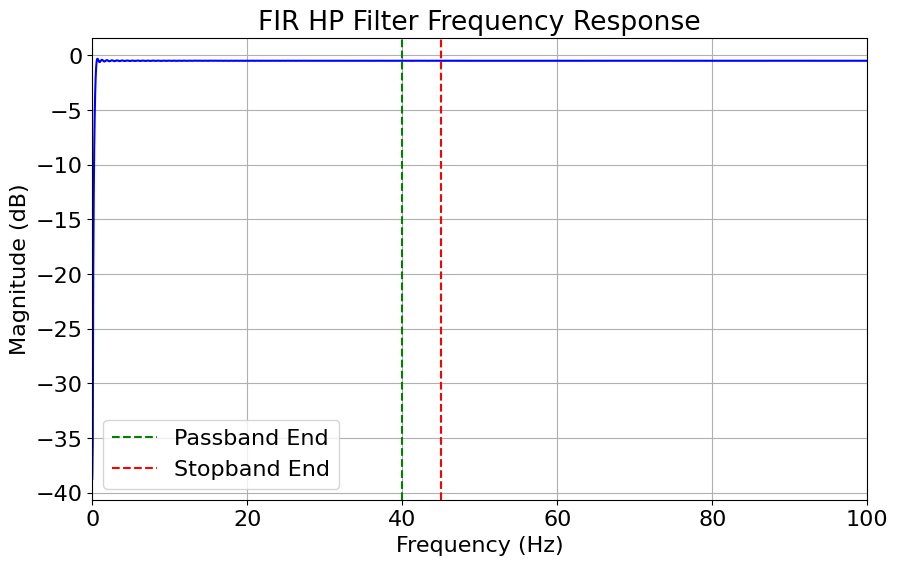

In [61]:
# High  pass

order = 3000  # Filter order (must be even for bandpass)

# Design the filter using firls
bh = sig.firls(order + 1, frecs_h, gains_h)

# Frequency response
w, h = sig.freqz(bh, worN=8000, fs=fs)

# Plot frequency response
plt.figure(figsize=(10, 6))
plt.plot(w, 20 * np.log10(abs(h)), 'b')
plt.title("FIR HP Filter Frequency Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.axvline(40, color='green', linestyle='--', label='Passband End')
plt.axvline(45, color='red', linestyle='--', label='Stopband End')
plt.xlim(0, 100)  # Limit the x-axis to 0-100 Hz
plt.legend()
plt.show()

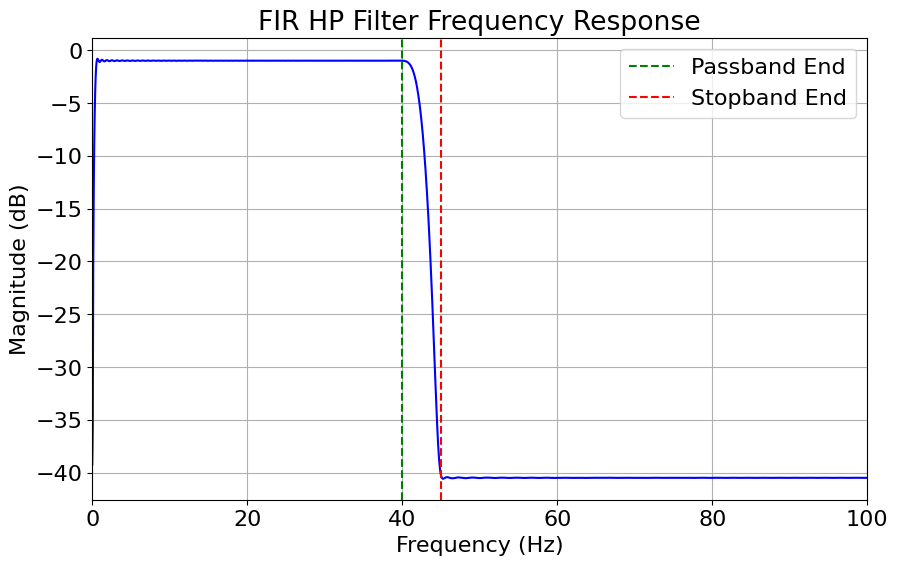

In [62]:
b_bp = sig.convolve(bh, bl)
# Frequency response
w, h = sig.freqz(b_bp, worN=8000, fs=fs)

# Plot frequency response
plt.figure(figsize=(10, 6))
plt.plot(w, 20 * np.log10(abs(h)), 'b')
plt.title("FIR HP Filter Frequency Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.axvline(40, color='green', linestyle='--', label='Passband End')
plt.axvline(45, color='red', linestyle='--', label='Stopband End')
plt.xlim(0, 100)  # Limit the x-axis to 0-100 Hz
plt.legend()
plt.show()

# Filtrado con FIR
Una vez obtenido nuestro filtro, procedemos nuevamente a filtrar la señal y observar su funcionamiento. En este caso si podemos corregir el retardo gracias a que este es constante.

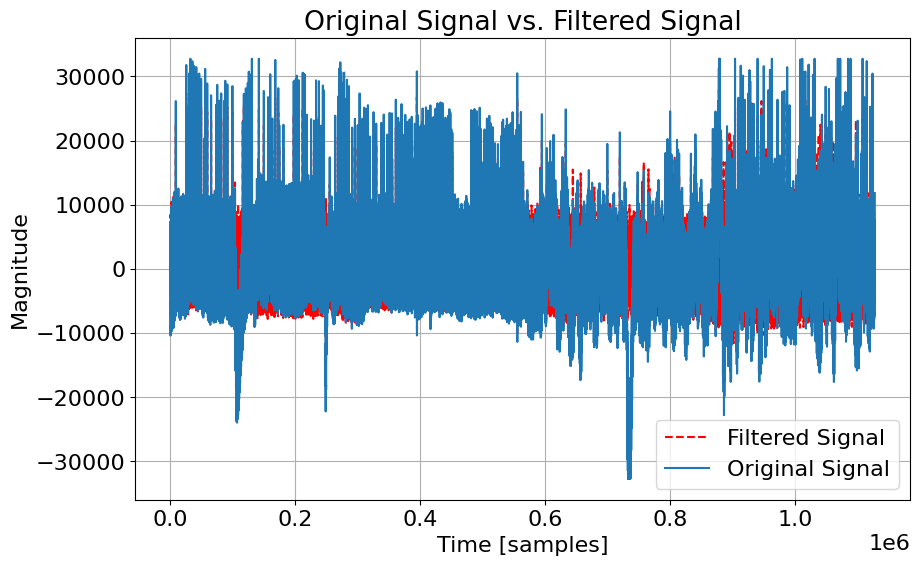

In [63]:
ecg_filter_2 = sig.lfilter(b_bp, 1, ecg_lead)

delay = 2000  

adjusted_filtered_signal = ecg_filter_2[delay:]

adjusted_original_signal = ecg_lead[:len(adjusted_filtered_signal)]

plt.figure(figsize=(10, 6))
plt.plot(adjusted_filtered_signal, "--r", label='Filtered Signal')
plt.plot(adjusted_original_signal, label='Original Signal')
plt.title("Original Signal vs. Filtered Signal")
plt.xlabel("Time [samples]")
plt.ylabel("Magnitude")
plt.grid()
plt.legend()
plt.show()


# Zonas de alta contaminación

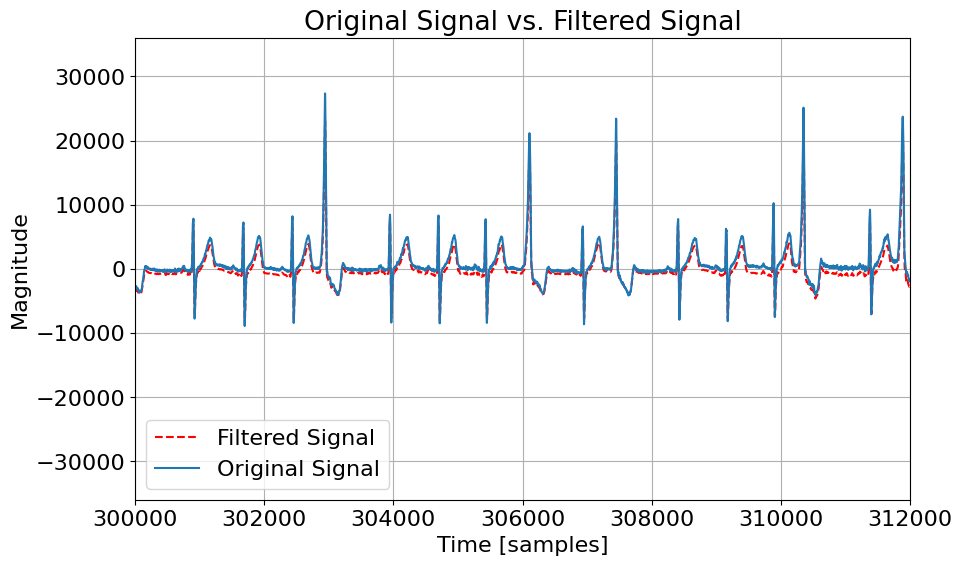

In [64]:
plt.figure(figsize=(10, 6))
plt.plot(adjusted_filtered_signal, "--r", label='Filtered Signal')
plt.plot(adjusted_original_signal, label='Original Signal')
plt.title("Original Signal vs. Filtered Signal")
plt.xlabel("Time [samples]")
plt.ylabel("Magnitude")
plt.xlim(300000,312000)
plt.grid()
plt.legend()
plt.show()

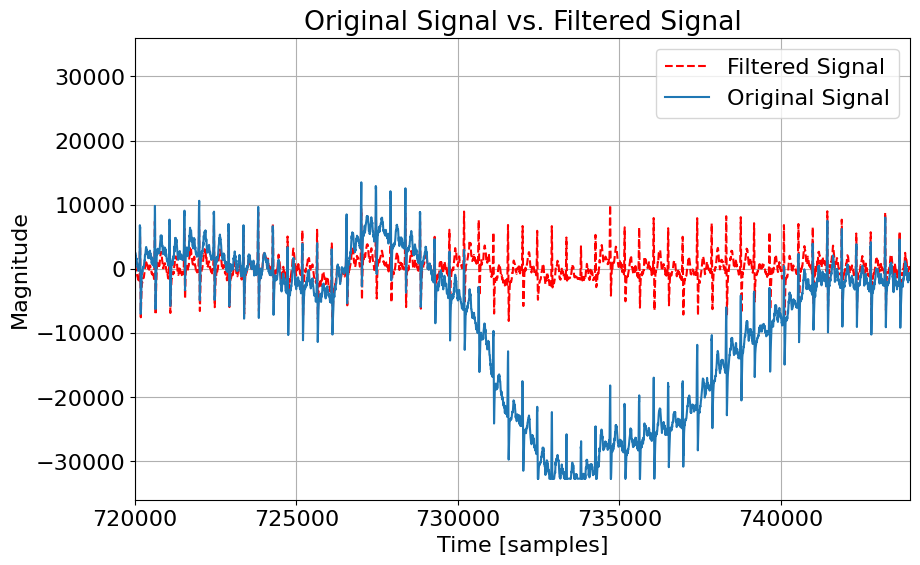

In [65]:
plt.figure(figsize=(10, 6))
plt.plot(adjusted_filtered_signal, "--r", label='Filtered Signal')
plt.plot(adjusted_original_signal, label='Original Signal')
plt.title("Original Signal vs. Filtered Signal")
plt.xlabel("Time [samples]")
plt.ylabel("Magnitude")
plt.xlim(720000,744000)
plt.grid()
plt.legend()
plt.show()

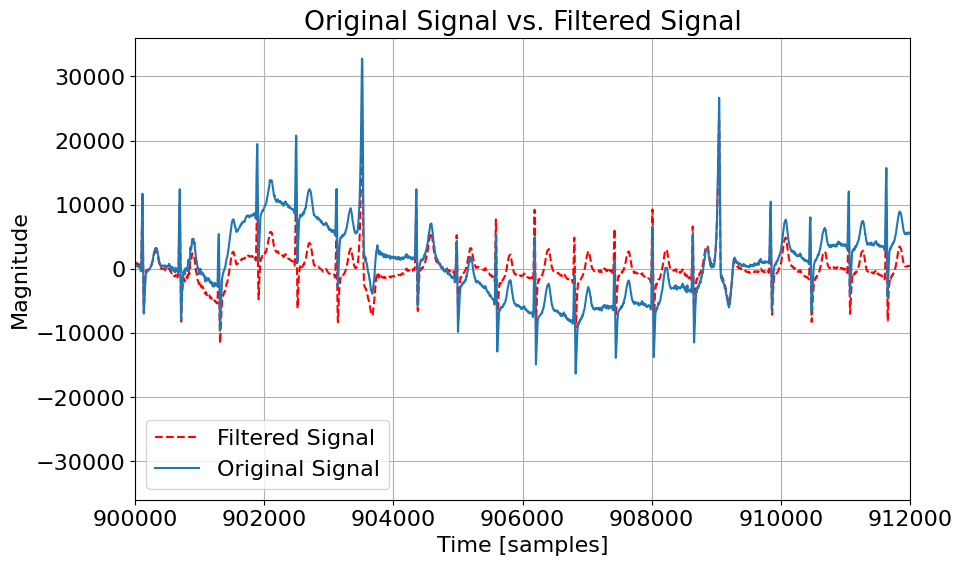

In [66]:
plt.figure(figsize=(10, 6))
plt.plot(adjusted_filtered_signal, "--r", label='Filtered Signal')
plt.plot(adjusted_original_signal, label='Original Signal')
plt.title("Original Signal vs. Filtered Signal")
plt.xlabel("Time [samples]")
plt.ylabel("Magnitude")
plt.xlim(900000,912000)
plt.grid()
plt.legend()
plt.show()

# Zonas de baja contaminación

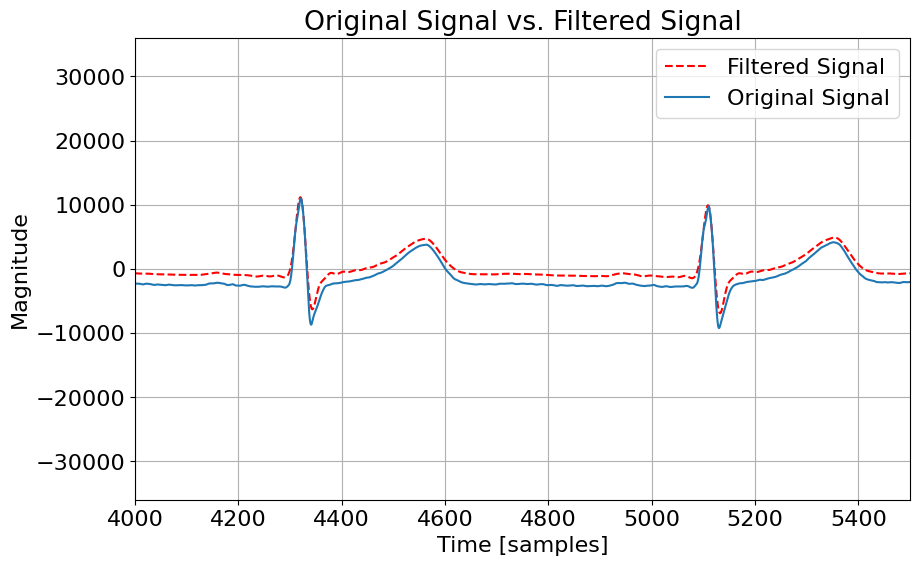

In [67]:
plt.figure(figsize=(10, 6))
plt.plot(adjusted_filtered_signal, "--r", label='Filtered Signal')
plt.plot(adjusted_original_signal, label='Original Signal')
plt.title("Original Signal vs. Filtered Signal")
plt.xlabel("Time [samples]")
plt.ylabel("Magnitude")
plt.xlim(4000,5500)
plt.grid()
plt.legend()
plt.show()

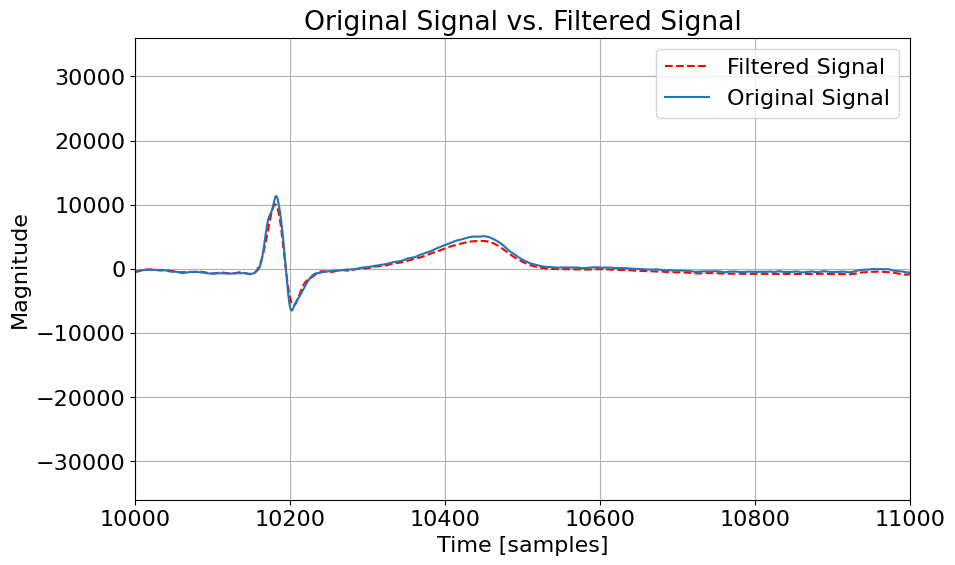

In [68]:
plt.figure(figsize=(10, 6))
plt.plot(adjusted_filtered_signal, "--r", label='Filtered Signal')
plt.plot(adjusted_original_signal, label='Original Signal')
plt.title("Original Signal vs. Filtered Signal")
plt.xlabel("Time [samples]")
plt.ylabel("Magnitude")
plt.xlim(10000,11000)
plt.grid()
plt.legend()
plt.show()

# Conclusión
Si bien el filtro IIR es mucho mas sencillo de diseñar, el FIR posee una clara ventaja sobre este y es mantener un retardo constante que puede ser corregido una vez filtrada la señal. Además pudimos observar en la comparativa de las señales originales vs las filtradas como el filtro FIR filtró adecuadamente las zonas contaminadas y no afectó las zonas sin contaminar.